# Tópicos em Otimização Irrestrita

### Pacotes importados

In [29]:
import Pkg
Pkg.add("Plots")

using Plots
using LinearAlgebra

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\morai\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\morai\.julia\environments\v1.12\Manifest.toml`


### Machine epsilon

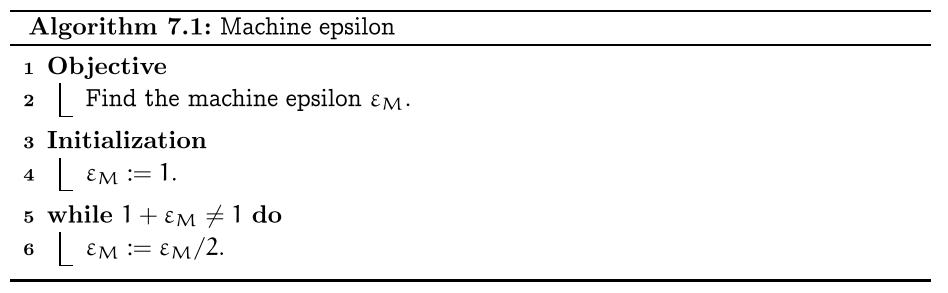

In [6]:
epsilon_M = 1.0

while 1.0 + epsilon_M != 1.0
    epsilon_M = epsilon_M / 2.0
end

println("Épsilon de máquina encontrado: ", epsilon_M)
println("Épsilon anterior válido: ", 2epsilon_M)

Épsilon de máquina encontrado: 1.1102230246251565e-16
Épsilon anterior válido: 2.220446049250313e-16


### Newton's method: one variable

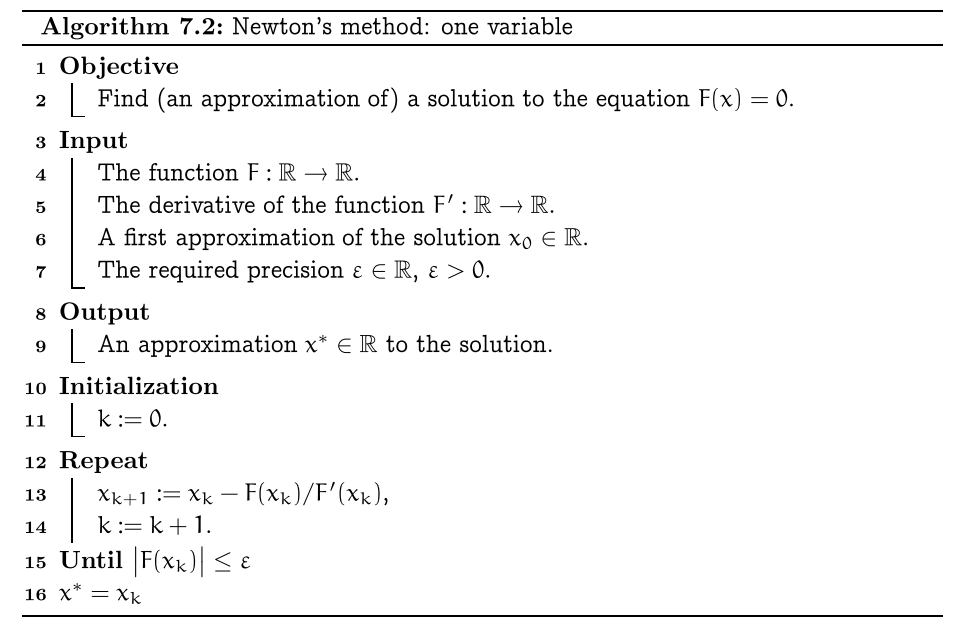

Take the equation: $F(x) = x^2 - 2 = 0$. Apply the Newton's method with $x_0 = 2, \epsilon = 10^{-15}$. Present the results such as the following:

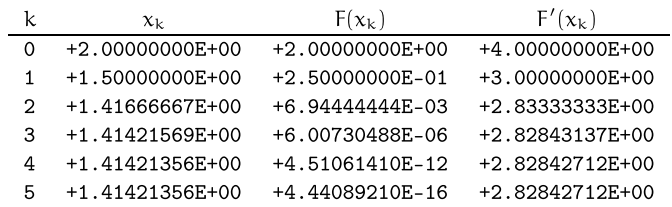

Also plot the graph with the iterations $\times$ the value of F(x).

Iterações do Método de Newton: [1.0, 1.5, 1.4166666666666667, 1.4142156862745099, 1.4142135623746899]
Raiz aproximada: 1.4142135623746899
Raiz exata: 1.4142135623730951


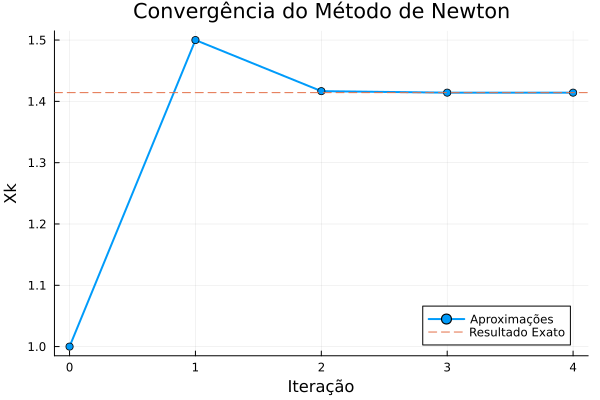

print device already activated


In [24]:
function newton_plot(F, dF, x0, epi; max_iter=100)
    x = x0
    xs = [x0]
    k = 0

    while abs(F(x)) > epi && k < max_iter
        x = x - F(x) / dF(x)
        push!(xs, x)
        k += 1
    end

    return xs
end

F(x) = x^2 - 2
dF(x) = 2x

println("Iterações do Método de Newton: ", newton_plot(F, dF, 1.0, 1e-8))
println("Raiz aproximada: ", newton_plot(F, dF, 1.0, 1e-8)[end])
println("Raiz exata: ", sqrt(2))
xs = newton_plot(F, dF, 1.0, 1e-8)
iteracoes = 0:length(xs)-1

plot(
    iteracoes,
    xs,
    marker=:circle,
    linewidth=2,
    xlabel="Iteração",
    ylabel="Xk",
    title="Convergência do Método de Newton",
    label="Aproximações"
)


hline!([sqrt(2)], linestyle=:dash, label="Resultado Exato")

Another example: $F(x)=x-\sin(x)$. Run the example with $x_0=1$ and $\varepsilon=10^{-15}$.

Raiz aproximada: 1.7074312016207497e-5
Iterações: 27
|F(x)|: 8.296179498587519e-16


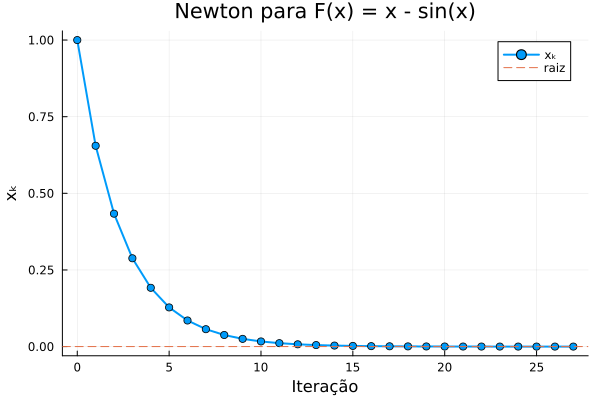

In [27]:


F(x) = x - sin(x)
dF(x) = 1 - cos(x)

x0 = 1.0
epi = 1e-15

xs = newton_plot(F, dF, x0, epi)

println("Raiz aproximada: ", xs[end])
println("Iterações: ", length(xs)-1)
println("|F(x)|: ", abs(F(xs[end])))

plot(
    0:length(xs)-1,
    xs,
    marker=:circle,
    linewidth=2,
    xlabel="Iteração",
    ylabel="xₖ",
    title="Newton para F(x) = x - sin(x)",
    label="xₖ"
)

hline!([0.0], linestyle=:dash, label="raiz")

Another example: $F(x)=\arctan(x)$. Run the example with $x_0=1.5$ and $\varepsilon=10^{-15}$. We set `maxiter` to 10, as the algorithm is not converging.

Iterações realizadas: 10
Última aproximação: 2.4539946374984955e108
|F(x)| final: 1.5707963267948966


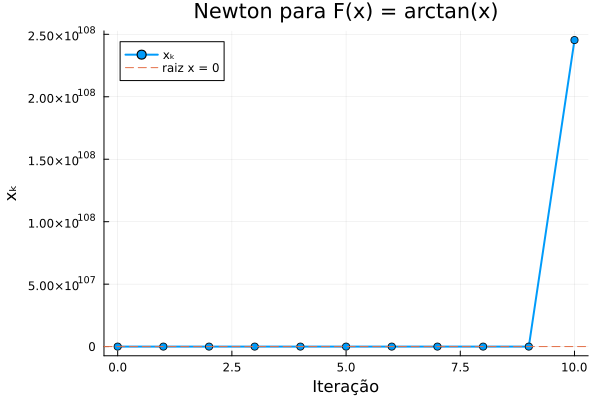

In [28]:
function newton_plot_2(F, dF, x0, epi; max_iter=10)
    x = x0
    xs = [x0]
    k = 0

    while abs(F(x)) > epi && k < max_iter
        x = x - F(x) / dF(x)
        push!(xs, x)
        k += 1
    end

    return xs, k
end

F(x) = atan(x)
dF(x) = 1 / (1 + x^2)

x0 = 1.5
epi = 1e-15

xs, iter = newton_plot_2(F, dF, x0, epi, max_iter=10)

println("Iterações realizadas: ", iter)
println("Última aproximação: ", xs[end])
println("|F(x)| final: ", abs(F(xs[end])))

plot(
    0:length(xs)-1,
    xs,
    marker=:circle,
    linewidth=2,
    xlabel="Iteração",
    ylabel="xₖ",
    title="Newton para F(x) = arctan(x)",
    label="xₖ"
)

hline!([0.0], linestyle=:dash, label="raiz x = 0")

### Algorithm 7.3: Newton's method: $n$ variables

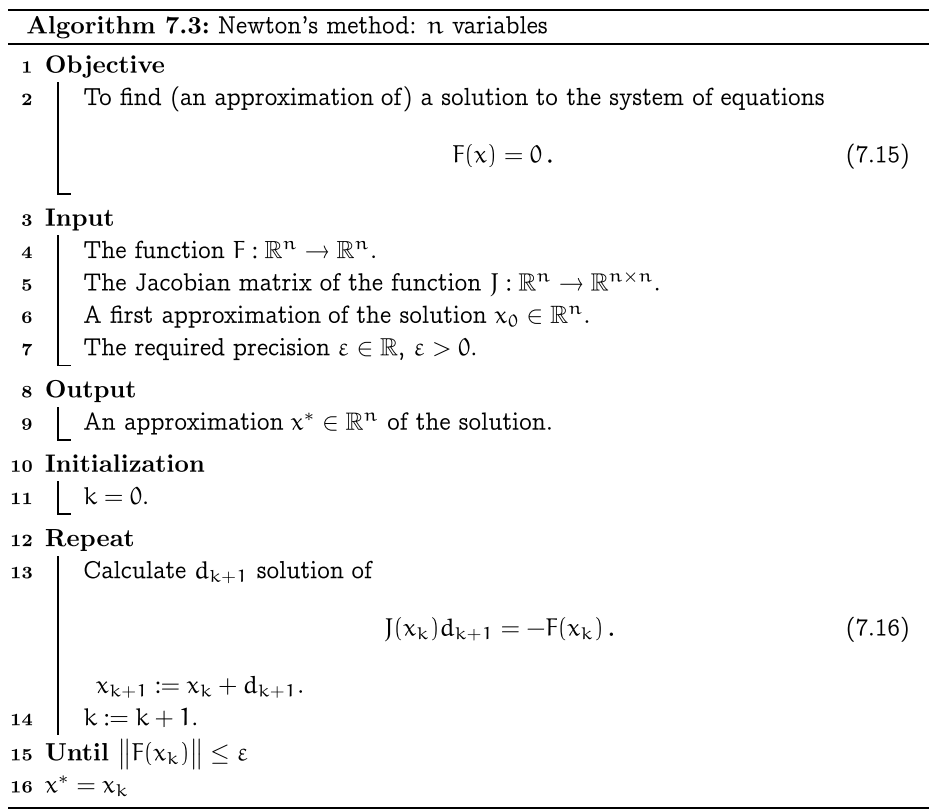

In [35]:
function newton_sistema_plot(F, J, x0, epi; max_iter=100)
    x = copy(x0)
    xs = [copy(x)]
    erros = [norm(F(x))]
    k = 0

    while norm(F(x)) > epi && k < max_iter
        d = J(x) \ (-F(x))
        x = x + d

        push!(xs, copy(x))
        push!(erros, norm(F(x)))

        k += 1
    end

    return x, xs, erros, k
end

newton_sistema_plot (generic function with 1 method)

Example: $F(x)=\left(\begin{array}{c}(x_1+1)^2+ x_2^2 - 2 \\ e^{x_1} + x_2^3 - 2 \end{array}\right)$. Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

Solução aproximada: [1.4142135623746899, 1.4142135623746899]
Iterações: 4
Norma final: 9.021228208894172e-12


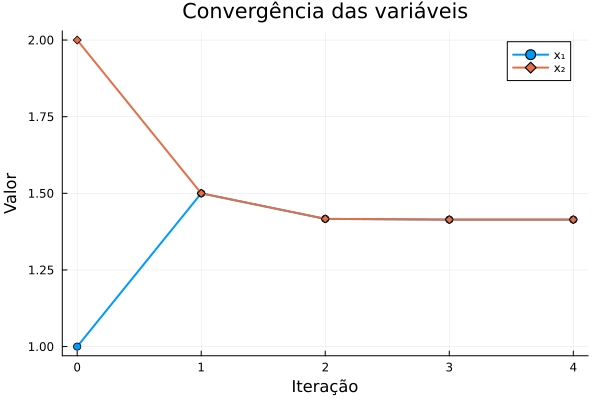

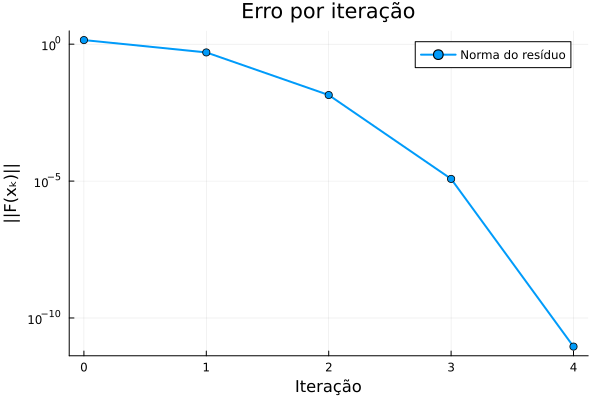

In [39]:
F(x) = [
    x[1]^2 + x[2]^2 - 4;
    x[1] - x[2]
]

J(x) = [
    2x[1]  2x[2];
    1      -1
]

x0 = [1.0, 2.0]
epi = 1e-10

x_aprox, xs, erros, iter = newton_sistema_plot(F, J, x0, epi)

x1_vals = [x[1] for x in xs]
x2_vals = [x[2] for x in xs]
k_vals = 0:length(xs)-1

println("Solução aproximada: ", x_aprox)
println("Iterações: ", iter)
println("Norma final: ", norm(F(x_aprox)))

p1 = plot(
    k_vals,
    x1_vals,
    marker=:circle,
    linewidth=2,
    xlabel="Iteração",
    ylabel="Valor",
    title="Convergência das variáveis",
    label="x₁"
)

plot!(
    p1,
    k_vals,
    x2_vals,
    marker=:diamond,
    linewidth=2,
    label="x₂"
)

display(p1)

p2 = plot(
    k_vals,
    erros,
    marker=:circle,
    linewidth=2,
    yscale=:log10,
    xlabel="Iteração",
    ylabel="||F(xₖ)||",
    title="Erro por iteração",
    label="Norma do resíduo"
)

display(p2)

Example: $F(x)=\left(\begin{array}{c}x_1^3 - 3 x_1 x_2^2 -1 \\ x_2^3 - 3x_1^2 x_2\end{array}\right)$. Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

Solução aproximada: [1.0, 4.930380657631324e-31]
Iterações: 9
Norma final: 1.4791141972893971e-30


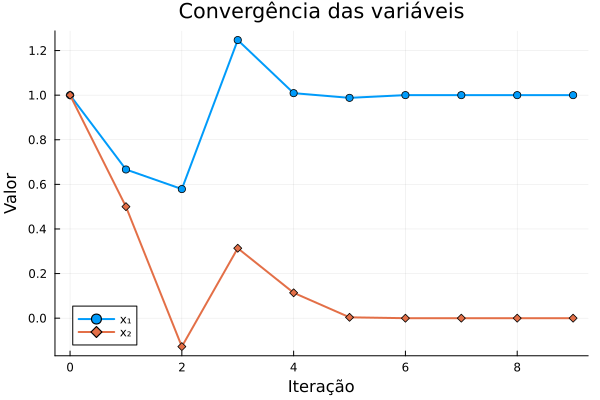

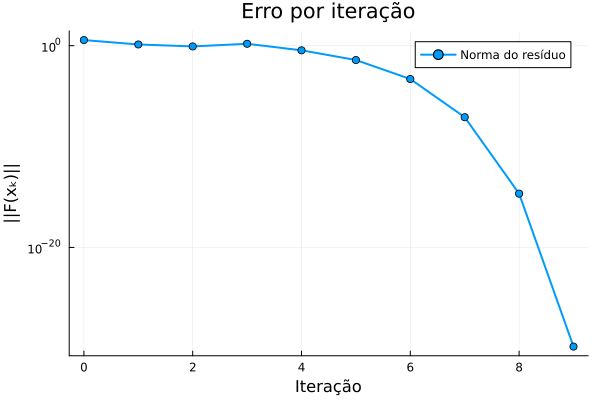

In [40]:
F(x) = [
    x[1]^3 - 3*x[1]*x[2]^2 - 1;
    x[2]^3 - 3*x[1]^2*x[2]
]

J(x) = [
    3*x[1]^2 - 3*x[2]^2    -6*x[1]*x[2];
    -6*x[1]*x[2]            3*x[2]^2 - 3*x[1]^2
]

x0 = [1.0, 1.0]
epi = 1e-15

x_aprox, xs, erros, iter = newton_sistema_plot(F, J, x0, epi)

x1_vals = [x[1] for x in xs]
x2_vals = [x[2] for x in xs]
k_vals = 0:length(xs)-1

println("Solução aproximada: ", x_aprox)
println("Iterações: ", iter)
println("Norma final: ", norm(F(x_aprox)))

p1 = plot(
    k_vals,
    x1_vals,
    marker=:circle,
    linewidth=2,
    xlabel="Iteração",
    ylabel="Valor",
    title="Convergência das variáveis",
    label="x₁"
)

plot!(
    p1,
    k_vals,
    x2_vals,
    marker=:diamond,
    linewidth=2,
    label="x₂"
)

display(p1)

p2 = plot(
    k_vals,
    erros,
    marker=:circle,
    linewidth=2,
    yscale=:log10,
    xlabel="Iteração",
    ylabel="||F(xₖ)||",
    title="Erro por iteração",
    label="Norma do resíduo"
)

display(p2)

Run the example with $x_0= \left(\begin{array}{c} -1 \\ -1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

Solução aproximada: [-0.49999999999999994, -0.8660254037844386]
Iterações: 6
Norma final: 2.482534153247273e-16


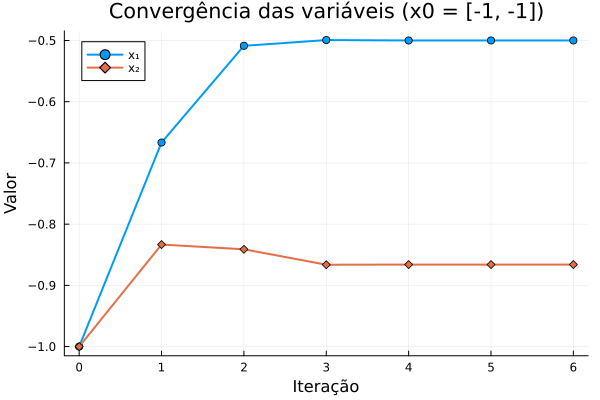

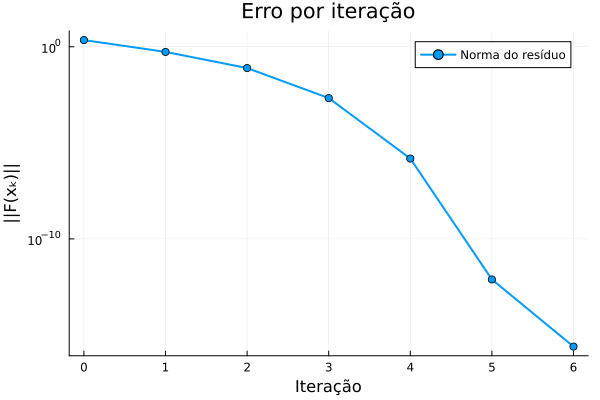

In [43]:
x0 = [-1.0, -1.0]   # novo ponto inicial
epi = 1e-15

x_aprox, xs, erros, iter = newton_sistema_plot(F, J, x0, epi)

x1_vals = [x[1] for x in xs]
x2_vals = [x[2] for x in xs]
k_vals = 0:length(xs)-1

println("Solução aproximada: ", x_aprox)
println("Iterações: ", iter)
println("Norma final: ", norm(F(x_aprox)))

p1 = plot(
    k_vals,
    x1_vals,
    marker=:circle,
    linewidth=2,
    xlabel="Iteração",
    ylabel="Valor",
    title="Convergência das variáveis (x0 = [-1, -1])",
    label="x₁"
)

plot!(
    p1,
    k_vals,
    x2_vals,
    marker=:diamond,
    linewidth=2,
    label="x₂"
)

display(p1)

p2 = plot(
    k_vals,
    erros,
    marker=:circle,
    linewidth=2,
    yscale=:log10,
    xlabel="Iteração",
    ylabel="||F(xₖ)||",
    title="Erro por iteração",
    label="Norma do resíduo"
)

display(p2)


Run the example with $x_0= \left(\begin{array}{c} 0 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

Solução aproximada: [-0.5000000000000001, 0.8660254037844387]
Iterações: 6
Norma final: 4.965068306494546e-16


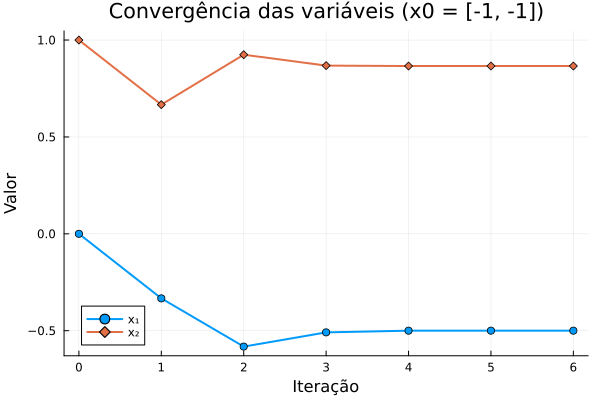

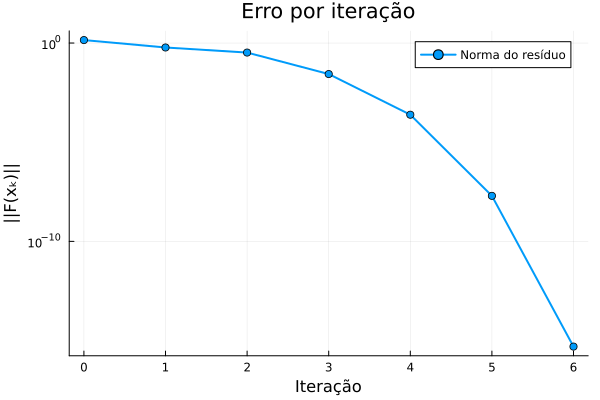

In [41]:
x0 = [0.0, 1.0]
epi = 1e-15

x_aprox, xs, erros, iter = newton_sistema_plot(F, J, x0, epi)

x1_vals = [x[1] for x in xs]
x2_vals = [x[2] for x in xs]
k_vals = 0:length(xs)-1

println("Solução aproximada: ", x_aprox)
println("Iterações: ", iter)
println("Norma final: ", norm(F(x_aprox)))

p1 = plot(
    k_vals,
    x1_vals,
    marker=:circle,
    linewidth=2,
    xlabel="Iteração",
    ylabel="Valor",
    title="Convergência das variáveis (x0 = [-1, -1])",
    label="x₁"
)

plot!(
    p1,
    k_vals,
    x2_vals,
    marker=:diamond,
    linewidth=2,
    label="x₂"
)

display(p1)

p2 = plot(
    k_vals,
    erros,
    marker=:circle,
    linewidth=2,
    yscale=:log10,
    xlabel="Iteração",
    ylabel="||F(xₖ)||",
    title="Erro por iteração",
    label="Norma do resíduo"
)

display(p2)